In [2]:
import os
import random
import csv
from collections import OrderedDict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt

In [5]:
import os
print(os.getcwd())

/


In [7]:
import os

for root, dirs, files in os.walk("/Users"):
    if "config.py" in files and "dataset.py" in files:
        print(root)

/Users/saral/Downloads/cyper/federated_heart_project


In [8]:
import os, sys

PROJECT_DIR = "/Users/saral/Downloads/cyper/federated_heart_project"

os.chdir(PROJECT_DIR)
sys.path.append(PROJECT_DIR)

print(os.getcwd())
print(os.listdir())

from config import Config
print("Config loaded ✅")

/Users/saral/Downloads/cyper/federated_heart_project
['Cardic disease complete code and data.zip', '.DS_Store', 'config.py', 'analysis_history.csv', 'federated_multitask_train.py', 'requirements.txt', 'train_feature_classifiers.py', 'ACDC_extracted', 'Cardic disease complete code and data', 'nabdh_logo.png', 'ACDC_extracted.zip', 'models', 'multitask_model.py', 'dataset.py', 'analyze_mri_features.py', 'extract_mri_features.py', '.gitignore', 'deeplab_model.py', 'build_pathology_map.py', 'app.py', 'Original.ipynb', 'federated_seg_train.py', 'fl_outputs', '.git']
Config loaded ✅


In [9]:
from dataset import (
    ACDCH5SliceDataset,
    split_patients_from_slices,
    build_client_subsets_from_indices,
)

print("Dataset loaded ✅")

Dataset loaded ✅


In [10]:
from deeplab_model import build_deeplab

print("DeepLab model loaded ✅")

DeepLab model loaded ✅


In [11]:
import os

print(Config.PREPROCESSED_SLICES_DIR)
print(os.path.isdir(Config.PREPROCESSED_SLICES_DIR))
print(len(os.listdir(Config.PREPROCESSED_SLICES_DIR)))

./ACDC_extracted/Cardic disease complete code and data/ACDC_preprocessed/ACDC_training_slices
True
1913


In [14]:
def seed_all(seed):
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def dice_loss(logits, targets, eps=1e-6):
    probs = F.softmax(logits, dim=1)
    onehot = F.one_hot(targets, num_classes=logits.shape[1]).permute(0, 3, 1, 2).float()

    dims = (0, 2, 3)
    inter = torch.sum(probs * onehot, dims)
    union = torch.sum(probs + onehot, dims)

    dice = (2 * inter + eps) / (union + eps)
    return 1.0 - dice.mean()


def get_weights(model):
    return OrderedDict((k, v.detach().cpu().clone()) for k, v in model.state_dict().items())


def set_weights(model, weights):
    model.load_state_dict(weights, strict=True)


def fedavg(client_weights, sizes):
    total = float(sum(sizes))
    avg = OrderedDict()

    for k in client_weights[0].keys():
        avg[k] = sum(w[k] * (n / total) for w, n in zip(client_weights, sizes))

    return avg


def ensure_single_channel(imgs):
    if imgs.dim() == 3:
        imgs = imgs.unsqueeze(1)
    elif imgs.dim() == 4 and imgs.shape[1] == 3:
        imgs = imgs.mean(dim=1, keepdim=True)
    elif imgs.dim() == 4 and imgs.shape[1] == 1:
        pass
    else:
        raise ValueError(f"Unexpected input shape: {imgs.shape}")
    return imgs


def ensure_single_channel_tensor(img):
    if img.dim() == 2:
        return img.unsqueeze(0)
    elif img.dim() == 3 and img.shape[0] == 3:
        return img.mean(dim=0, keepdim=True)
    elif img.dim() == 3 and img.shape[0] == 1:
        return img
    else:
        raise ValueError(f"Unexpected tensor shape: {img.shape}")


def disease_label_to_int(label):
    mapping = {
        "NOR": 0,
        "DCM": 1,
        "HCM": 2,
        "MINF": 3,
        "RV": 4
    }

    if torch.is_tensor(label):
        return label.long()

    if isinstance(label, (list, tuple)):
        return torch.tensor([mapping.get(str(x), 0) for x in label], dtype=torch.long)

    if isinstance(label, str):
        return torch.tensor(mapping.get(label, 0), dtype=torch.long)

    return torch.tensor(label, dtype=torch.long)


def extract_disease_labels_from_batch(batch, imgs):
    if len(batch) >= 4:
        labels = batch[3]

        if torch.is_tensor(labels):
            return labels.long()

        if isinstance(labels, (list, tuple)):
            return torch.tensor(
                [disease_label_to_int(x).item() for x in labels],
                dtype=torch.long
            )

        return disease_label_to_int(labels).view(-1)

    return torch.zeros(imgs.size(0), dtype=torch.long)


def extract_single_disease_label(rest):
    mapping = {
        "NOR": 0,
        "DCM": 1,
        "HCM": 2,
        "MINF": 3,
        "RV": 4
    }

    if len(rest) >= 2:
        label = rest[1]

        if torch.is_tensor(label):
            return int(label.item())

        if isinstance(label, str):
            return mapping.get(label, 0)

        return int(label)

    return 0

In [15]:
seed_all(Config.SEED)

print("Utilities loaded ✅")
print("Device:", Config.DEVICE)

print(disease_label_to_int("NOR"))
print(disease_label_to_int("DCM"))
print(disease_label_to_int("HCM"))
print(disease_label_to_int("MINF"))
print(disease_label_to_int("RV"))

Utilities loaded ✅
Device: cpu
tensor(0)
tensor(1)
tensor(2)
tensor(3)
tensor(4)


In [16]:
# =========================================
# Local ACGAN
# =========================================
class SimpleGenerator(nn.Module):
    """
    ACGAN Generator:
    Takes random noise vector z + disease class label.
    """
    def __init__(self, z_dim=64, num_classes=5, img_size=256, embed_dim=32):
        super().__init__()
        self.z_dim = z_dim
        self.img_size = img_size

        self.label_emb = nn.Embedding(num_classes, embed_dim)

        self.fc = nn.Linear(z_dim + embed_dim, 128 * 16 * 16)

        self.net = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1),   # 16 -> 32
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 32, 4, 2, 1),    # 32 -> 64
            nn.BatchNorm2d(32),
            nn.ReLU(True),

            nn.ConvTranspose2d(32, 16, 4, 2, 1),    # 64 -> 128
            nn.BatchNorm2d(16),
            nn.ReLU(True),

            nn.ConvTranspose2d(16, 8, 4, 2, 1),     # 128 -> 256
            nn.BatchNorm2d(8),
            nn.ReLU(True),

            nn.Conv2d(8, 1, kernel_size=3, padding=1),
            nn.Tanh()
        )

    def forward(self, z, labels):
        label_vec = self.label_emb(labels)
        x = torch.cat([z, label_vec], dim=1)
        x = self.fc(x).view(z.size(0), 128, 16, 16)
        return self.net(x)


class SimpleDiscriminator(nn.Module):
    """
    ACGAN Discriminator:
    Outputs:
    1. validity score: real/fake
    2. class logits: disease class prediction
    """
    def __init__(self, num_classes=5):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 4, 2, 1),   # 256 -> 128
            nn.LeakyReLU(0.2, True),

            nn.Conv2d(16, 32, 4, 2, 1),  # 128 -> 64
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2, True),

            nn.Conv2d(32, 64, 4, 2, 1),  # 64 -> 32
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, True),

            nn.Conv2d(64, 128, 4, 2, 1), # 32 -> 16
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, True),

            nn.AdaptiveAvgPool2d(1)
        )

        self.adv_head = nn.Linear(128, 1)
        self.cls_head = nn.Linear(128, num_classes)

    def forward(self, x):
        f = self.features(x).flatten(1)
        validity = self.adv_head(f)
        class_logits = self.cls_head(f)
        return validity, class_logits


def train_local_gan(loader, client_id, round_id, save_dir, z_dim=64, gan_epochs=1):
    """
    Trains a local ACGAN on client images only.
    Returns trained generator.
    """
    G = SimpleGenerator(
        z_dim=z_dim,
        num_classes=Config.NUM_DISEASE_CLASSES
    ).to(Config.DEVICE)

    D = SimpleDiscriminator(
        num_classes=Config.NUM_DISEASE_CLASSES
    ).to(Config.DEVICE)

    opt_g = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
    opt_d = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))

    bce = nn.BCEWithLogitsLoss()
    ce = nn.CrossEntropyLoss()

    G.train()
    D.train()

    for ep in range(gan_epochs):
        g_loss_sum = 0.0
        d_loss_sum = 0.0
        d_adv_sum = 0.0
        d_cls_sum = 0.0
        g_adv_sum = 0.0
        g_cls_sum = 0.0
        num_batches = 0

        for batch in loader:
            imgs = batch[0]
            labels = extract_disease_labels_from_batch(batch, imgs)

            imgs = imgs.to(Config.DEVICE)
            labels = labels.to(Config.DEVICE).long()

            imgs = ensure_single_channel(imgs)
            real = imgs * 2.0 - 1.0

            n = real.size(0)
            z = torch.randn(n, z_dim, device=Config.DEVICE)
            fake = G(z, labels)

            ones = torch.ones((n, 1), device=Config.DEVICE)
            zeros = torch.zeros((n, 1), device=Config.DEVICE)

            # -------------------------
            # Train Discriminator
            # -------------------------
            real_validity, real_cls = D(real)
            fake_validity, fake_cls = D(fake.detach())

            d_adv_loss = bce(real_validity, ones) + bce(fake_validity, zeros)
            d_cls_loss = ce(real_cls, labels)

            d_loss = d_adv_loss + d_cls_loss

            opt_d.zero_grad()
            d_loss.backward()
            opt_d.step()

            # -------------------------
            # Train Generator
            # -------------------------
            fake_validity, fake_cls = D(fake)

            g_adv_loss = bce(fake_validity, ones)
            g_cls_loss = ce(fake_cls, labels)

            g_loss = g_adv_loss + g_cls_loss

            opt_g.zero_grad()
            g_loss.backward()
            opt_g.step()

            d_loss_sum += d_loss.item()
            g_loss_sum += g_loss.item()
            d_adv_sum += d_adv_loss.item()
            d_cls_sum += d_cls_loss.item()
            g_adv_sum += g_adv_loss.item()
            g_cls_sum += g_cls_loss.item()
            num_batches += 1

        print(
            f"[ACGAN] Client {client_id} | Round {round_id} | "
            f"Epoch {ep+1}/{gan_epochs} | "
            f"D_loss={d_loss_sum/max(1, num_batches):.4f} | "
            f"G_loss={g_loss_sum/max(1, num_batches):.4f} | "
            f"D_adv={d_adv_sum/max(1, num_batches):.4f} | "
            f"D_cls={d_cls_sum/max(1, num_batches):.4f} | "
            f"G_adv={g_adv_sum/max(1, num_batches):.4f} | "
            f"G_cls={g_cls_sum/max(1, num_batches):.4f}"
        )

    os.makedirs(save_dir, exist_ok=True)
    gan_path = os.path.join(save_dir, f"client_{client_id}_round_{round_id}_acgan.pt")
    torch.save({"G": G.state_dict(), "D": D.state_dict()}, gan_path)
    print(f"[ACGAN] Saved local ACGAN: {gan_path}")

    return G

In [17]:
G = SimpleGenerator(
    z_dim=64,
    num_classes=Config.NUM_DISEASE_CLASSES
).to(Config.DEVICE)

D = SimpleDiscriminator(
    num_classes=Config.NUM_DISEASE_CLASSES
).to(Config.DEVICE)

print("Generator OK ✅")
print("Discriminator OK ✅")
print("Device:", Config.DEVICE)

Generator OK ✅
Discriminator OK ✅
Device: cpu


In [18]:
z = torch.randn(1, 64, device=Config.DEVICE)
label = torch.tensor([0], device=Config.DEVICE)

fake_img = G(z, label)

print(fake_img.shape)

torch.Size([1, 1, 256, 256])


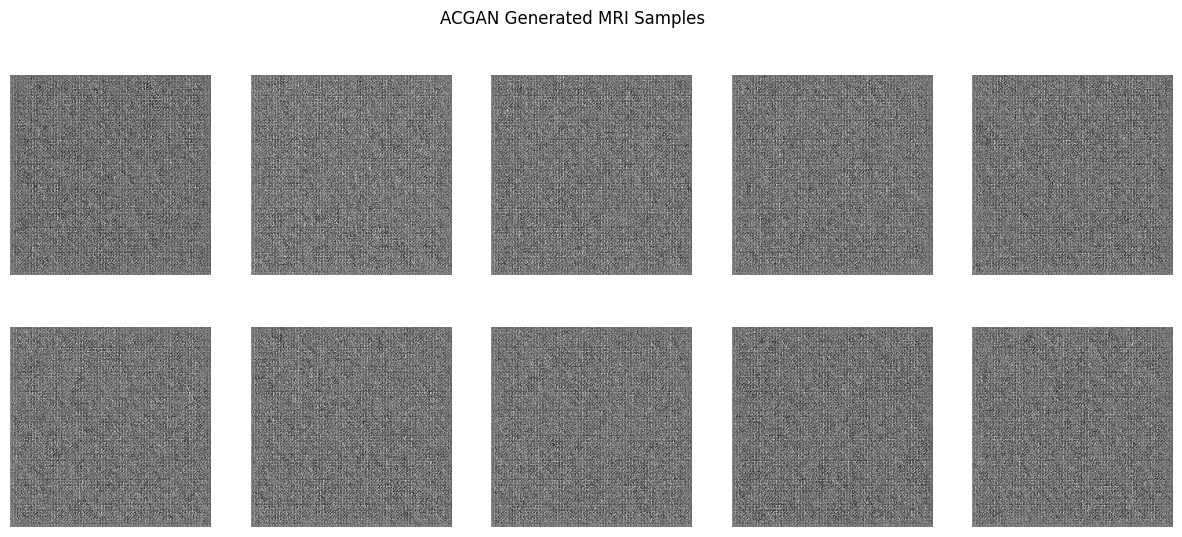

In [19]:
fig, axes = plt.subplots(2,5,figsize=(15,6))

for i,ax in enumerate(axes.flat):

    z = torch.randn(1,64,device=Config.DEVICE)
    label = torch.tensor([0],device=Config.DEVICE)

    with torch.no_grad():
        fake = G(z,label)

    fake = (fake.squeeze().cpu()+1)/2

    ax.imshow(fake,cmap='gray')
    ax.axis('off')

plt.suptitle("ACGAN Generated MRI Samples")
plt.show()

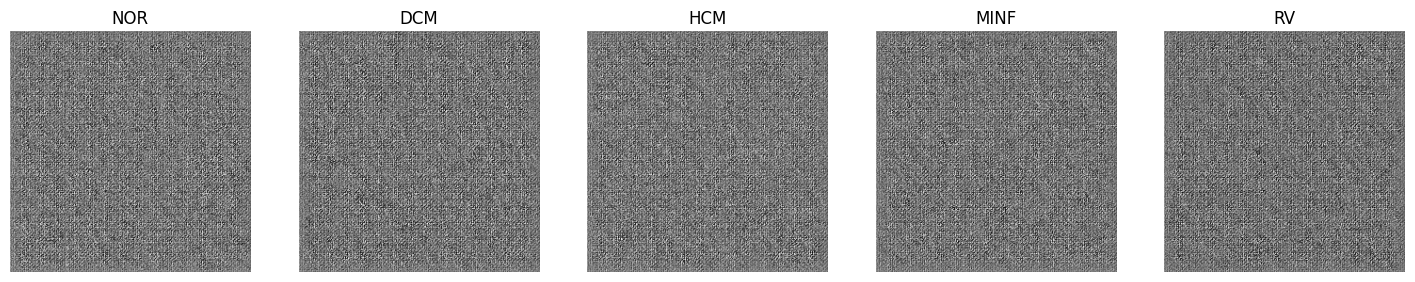

In [20]:
labels = {
    0:"NOR",
    1:"DCM",
    2:"HCM",
    3:"MINF",
    4:"RV"
}

fig,axes = plt.subplots(1,5,figsize=(18,5))

for disease_id,ax in enumerate(axes):

    z = torch.randn(1,64,device=Config.DEVICE)
    lbl = torch.tensor([disease_id],device=Config.DEVICE)

    with torch.no_grad():
        fake = G(z,lbl)

    fake = (fake.squeeze().cpu()+1)/2

    ax.imshow(fake,cmap='gray')
    ax.set_title(labels[disease_id])
    ax.axis('off')

plt.show()

In [21]:
train_indices, val_indices = split_patients_from_slices(
    Config.PREPROCESSED_SLICES_DIR,
    Config.VAL_RATIO,
    Config.SEED
)

client_datasets = build_client_subsets_from_indices(
    Config.PREPROCESSED_SLICES_DIR,
    train_indices,
    Config.NUM_CLIENTS,
    Config.SEED
)

client0 = client_datasets[0]

loader0 = DataLoader(
    client0,
    batch_size=Config.BATCH_SIZE,
    shuffle=True
)

print("Client 0 samples:", len(client0))

Client 0 samples: 300


In [22]:
gan_dir = os.path.join(Config.OUTPUT_DIR, "local_acgans")

G_trained = train_local_gan(
    loader=loader0,
    client_id=0,
    round_id=1,
    save_dir=gan_dir,
    z_dim=64,
    gan_epochs=1
)

print("ACGAN trained ✅")

[ACGAN] Client 0 | Round 1 | Epoch 1/1 | D_loss=2.7268 | G_loss=2.3901 | D_adv=1.3104 | D_cls=1.4163 | G_adv=0.7432 | G_cls=1.6469
[ACGAN] Saved local ACGAN: fl_outputs/local_acgans/client_0_round_1_acgan.pt
ACGAN trained ✅


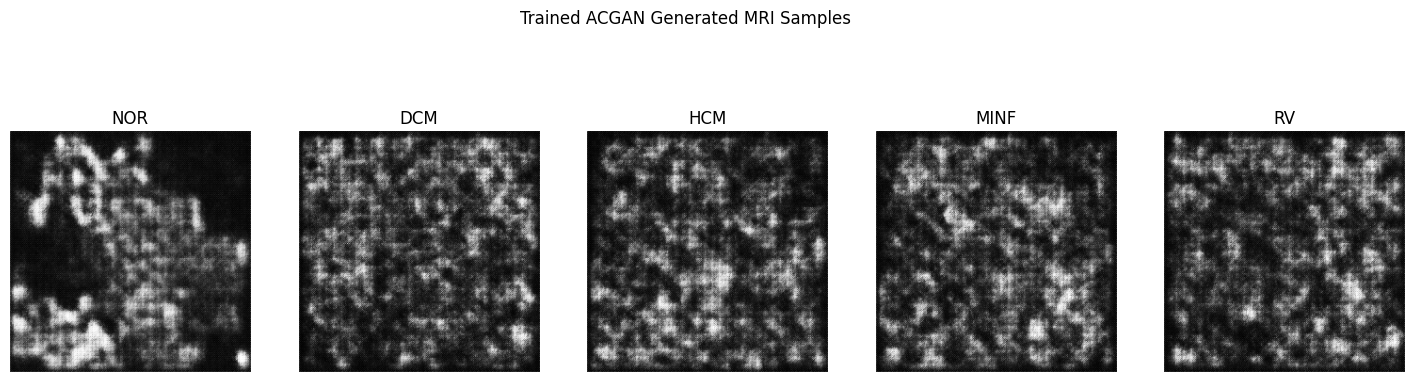

In [25]:
labels = {
    0:"NOR",
    1:"DCM",
    2:"HCM",
    3:"MINF",
    4:"RV"
}

fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for disease_id, ax in enumerate(axes):
    z = torch.randn(1, 64, device=Config.DEVICE)
    lbl = torch.tensor([disease_id], device=Config.DEVICE)

    with torch.no_grad():
        fake = G_trained(z, lbl)

    fake = (fake.squeeze().cpu() + 1) / 2

    ax.imshow(fake, cmap="gray")
    ax.set_title(labels[disease_id])
    ax.axis("off")

plt.suptitle("Trained ACGAN Generated MRI Samples")
plt.show()

In [24]:
G_trained = train_local_gan(
    loader=loader0,
    client_id=0,
    round_id=1,
    save_dir=gan_dir,
    z_dim=64,
    gan_epochs=5
)

[ACGAN] Client 0 | Round 1 | Epoch 1/5 | D_loss=2.3750 | G_loss=1.8633 | D_adv=1.3204 | D_cls=1.0546 | G_adv=0.7190 | G_cls=1.1443
[ACGAN] Client 0 | Round 1 | Epoch 2/5 | D_loss=1.8964 | G_loss=1.5067 | D_adv=1.2446 | D_cls=0.6518 | G_adv=0.7506 | G_cls=0.7562
[ACGAN] Client 0 | Round 1 | Epoch 3/5 | D_loss=1.7329 | G_loss=1.2164 | D_adv=1.2926 | D_cls=0.4402 | G_adv=0.7721 | G_cls=0.4443
[ACGAN] Client 0 | Round 1 | Epoch 4/5 | D_loss=1.6091 | G_loss=1.0632 | D_adv=1.3082 | D_cls=0.3009 | G_adv=0.7678 | G_cls=0.2954
[ACGAN] Client 0 | Round 1 | Epoch 5/5 | D_loss=1.5262 | G_loss=0.9604 | D_adv=1.3113 | D_cls=0.2149 | G_adv=0.7445 | G_cls=0.2158
[ACGAN] Saved local ACGAN: fl_outputs/local_acgans/client_0_round_1_acgan.pt


In [26]:
# =========================================
# Augmented Local Dataset
# =========================================
class MixedAugmentedDataset(Dataset):
    """
    Mixes:
    - original real samples
    - synthetic image samples generated locally by ACGAN

    For simplicity, each synthetic image reuses a randomly selected real mask.
    The synthetic image is conditioned on the disease label of that selected real sample.
    """
    def __init__(self, base_dataset, generator, num_synthetic=100, z_dim=64):
        self.base_dataset = base_dataset
        self.generator = generator
        self.num_synthetic = num_synthetic
        self.z_dim = z_dim

        self.synthetic_cache = []
        self._build_synthetic_cache()

    def _build_synthetic_cache(self):
        self.generator.eval()
        self.synthetic_cache = []

        with torch.no_grad():
            for _ in range(self.num_synthetic):
                idx = random.randint(0, len(self.base_dataset) - 1)
                real_img, real_mask, *rest = self.base_dataset[idx]

                disease_label = extract_single_disease_label(rest)
                label_tensor = torch.tensor(
                    [disease_label],
                    device=Config.DEVICE,
                    dtype=torch.long
                )

                z = torch.randn(1, self.z_dim, device=Config.DEVICE)

                fake_img = self.generator(z, label_tensor).squeeze(0).cpu()
                fake_img = (fake_img + 1.0) / 2.0
                fake_img = torch.clamp(fake_img, 0.0, 1.0)

                fake_img = ensure_single_channel_tensor(fake_img)
                self.synthetic_cache.append((fake_img, real_mask.clone()))

    def __len__(self):
        return len(self.base_dataset) + len(self.synthetic_cache)

    def __getitem__(self, idx):
        if idx < len(self.base_dataset):
            item = self.base_dataset[idx]
            img, mask = item[0], item[1]

            img = ensure_single_channel_tensor(img)

            return img.float(), mask.long()

        sidx = idx - len(self.base_dataset)
        img, mask = self.synthetic_cache[sidx]

        img = ensure_single_channel_tensor(img)

        return img.float(), mask.long()


In [27]:
mixed_dataset = MixedAugmentedDataset(
    base_dataset=client0,
    generator=G_trained,
    num_synthetic=10,
    z_dim=64
)

print("Real samples:", len(client0))
print("Mixed samples:", len(mixed_dataset))
print("Synthetic samples:", len(mixed_dataset) - len(client0))

Real samples: 300
Mixed samples: 310
Synthetic samples: 10


Image shape: torch.Size([1, 256, 256])
Mask shape: torch.Size([256, 256])


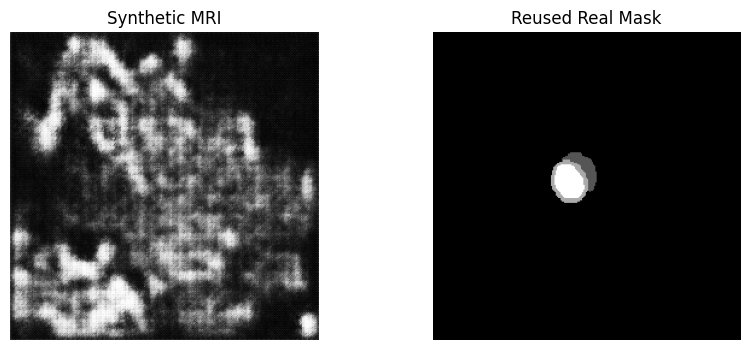

In [28]:
img, mask = mixed_dataset[len(client0)]

print("Image shape:", img.shape)
print("Mask shape:", mask.shape)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img.squeeze(), cmap="gray")
plt.title("Synthetic MRI")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Reused Real Mask")
plt.axis("off")

plt.show()

In [29]:

# =========================================
# Local DeepLab training
# =========================================
def train_local(global_weights, client_dataset, client_id, round_id):
    model = build_deeplab(num_seg_classes=Config.NUM_SEG_CLASSES).to(Config.DEVICE)
    set_weights(model, global_weights)

    real_loader = DataLoader(
        client_dataset,
        batch_size=Config.BATCH_SIZE,
        shuffle=True
    )

    # -------------------------
    # 1) Train local ACGAN
    # -------------------------
    gan_dir = os.path.join(Config.OUTPUT_DIR, "local_acgans")
    G = train_local_gan(
        loader=real_loader,
        client_id=client_id,
        round_id=round_id,
        save_dir=gan_dir,
        z_dim=64,
        gan_epochs=1
    )

    # -------------------------
    # 2) Build mixed dataset
    # -------------------------
    synthetic_count = min(50, len(client_dataset))
    mixed_dataset = MixedAugmentedDataset(
        base_dataset=client_dataset,
        generator=G,
        num_synthetic=synthetic_count,
        z_dim=64
    )

    mixed_loader = DataLoader(
        mixed_dataset,
        batch_size=Config.BATCH_SIZE,
        shuffle=True
    )

    print(
        f"[DeepLab] Client {client_id} | Round {round_id} | "
        f"Real={len(client_dataset)} | Synthetic={synthetic_count} | "
        f"Total={len(mixed_dataset)}"
    )

    # -------------------------
    # 3) Train local DeepLab
    # -------------------------
    opt = torch.optim.Adam(model.parameters(), lr=Config.LR)
    model.train()

    for ep in range(Config.LOCAL_EPOCHS):
        loss_sum = 0.0
        num_batches = 0

        for imgs, masks in mixed_loader:
            imgs = imgs.to(Config.DEVICE)
            masks = masks.to(Config.DEVICE)

            imgs = ensure_single_channel(imgs)

            opt.zero_grad()
            outputs = model(imgs)
            logits = outputs["out"] if isinstance(outputs, dict) else outputs

            loss = 0.5 * F.cross_entropy(logits, masks) + 0.5 * dice_loss(logits, masks)

            loss.backward()
            opt.step()

            loss_sum += loss.item()
            num_batches += 1

        print(
            f"[DeepLab] Client {client_id} | Round {round_id} | "
            f"Epoch {ep+1}/{Config.LOCAL_EPOCHS} | "
            f"Train Loss={loss_sum/max(1, num_batches):.4f}"
        )

    return get_weights(model), len(mixed_dataset)



In [30]:
global_model = build_deeplab(
    num_seg_classes=Config.NUM_SEG_CLASSES
).to(Config.DEVICE)

global_weights = get_weights(global_model)

print("Global DeepLab initialized ✅")

Global DeepLab initialized ✅


In [31]:
w0, size0 = train_local(
    global_weights=global_weights,
    client_dataset=client0,
    client_id=0,
    round_id=1
)

print("Client 0 completed ✅")
print("Effective dataset size:", size0)

[ACGAN] Client 0 | Round 1 | Epoch 1/1 | D_loss=2.4459 | G_loss=2.0044 | D_adv=1.3151 | D_cls=1.1308 | G_adv=0.7575 | G_cls=1.2469
[ACGAN] Saved local ACGAN: fl_outputs/local_acgans/client_0_round_1_acgan.pt
[DeepLab] Client 0 | Round 1 | Real=300 | Synthetic=50 | Total=350
[DeepLab] Client 0 | Round 1 | Epoch 1/1 | Train Loss=0.7085
Client 0 completed ✅
Effective dataset size: 350


In [32]:
def compute_segmentation_metrics(logits, masks, num_classes, eps=1e-6):
    preds = torch.argmax(logits, dim=1)

    pixel_acc = (preds == masks).float().mean().item()

    dice_scores = []
    iou_scores = []

    for cls in range(num_classes):
        pred_cls = (preds == cls).float()
        mask_cls = (masks == cls).float()

        intersection = (pred_cls * mask_cls).sum()
        pred_sum = pred_cls.sum()
        mask_sum = mask_cls.sum()
        union = pred_sum + mask_sum - intersection

        if mask_sum.item() == 0 and pred_sum.item() == 0:
            continue

        dice = (2.0 * intersection + eps) / (pred_sum + mask_sum + eps)
        iou = (intersection + eps) / (union + eps)

        dice_scores.append(dice.item())
        iou_scores.append(iou.item())

    mean_dice = sum(dice_scores) / len(dice_scores) if dice_scores else 0.0
    mean_iou = sum(iou_scores) / len(iou_scores) if iou_scores else 0.0

    return pixel_acc, mean_dice, mean_iou


def evaluate_model(model, loader):
    model.eval()

    total_loss = 0.0
    total_pixel_acc = 0.0
    total_dice = 0.0
    total_iou = 0.0
    num_batches = 0

    with torch.no_grad():
        for imgs, masks, _, _ in loader:
            imgs = imgs.to(Config.DEVICE)
            masks = masks.to(Config.DEVICE)

            imgs = ensure_single_channel(imgs)

            outputs = model(imgs)
            logits = outputs["out"] if isinstance(outputs, dict) else outputs

            loss = F.cross_entropy(logits, masks)
            pixel_acc, mean_dice, mean_iou = compute_segmentation_metrics(
                logits, masks, Config.NUM_SEG_CLASSES
            )

            total_loss += loss.item()
            total_pixel_acc += pixel_acc
            total_dice += mean_dice
            total_iou += mean_iou
            num_batches += 1

    if num_batches == 0:
        return 0.0, 0.0, 0.0, 0.0

    return (
        total_loss / num_batches,
        total_pixel_acc / num_batches,
        total_dice / num_batches,
        total_iou / num_batches,
    )

In [33]:
print("Evaluation functions loaded ✅")

Evaluation functions loaded ✅


In [34]:
seed_all(Config.SEED)
os.makedirs(Config.OUTPUT_DIR, exist_ok=True)

slices_dir = Config.PREPROCESSED_SLICES_DIR

train_indices, val_indices = split_patients_from_slices(
    slices_dir,
    Config.VAL_RATIO,
    Config.SEED
)

val_dataset = ACDCH5SliceDataset(
    slices_dir=slices_dir,
    indices=val_indices,
    augment=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=Config.BATCH_SIZE,
    shuffle=False
)

client_datasets = build_client_subsets_from_indices(
    slices_dir,
    train_indices,
    Config.NUM_CLIENTS,
    Config.SEED
)

print("Validation:",len(val_dataset))

for cid,ds in client_datasets.items():
    print(cid,len(ds))

Validation: 376
0 300
1 302
2 304
3 344
4 286


In [35]:
global_model = build_deeplab(
    num_seg_classes=Config.NUM_SEG_CLASSES
).to(Config.DEVICE)

global_weights = get_weights(global_model)

best_mean_dice = -1.0
results_log = []

print("Global Model Ready")

Global Model Ready


In [36]:
rnd=0

client_weights=[]
sizes=[]


for cid,ds in client_datasets.items():

    print(f"\nClient {cid}")

    w,size=train_local(
        global_weights,
        ds,
        cid,
        rnd+1
    )

    client_weights.append(w)
    sizes.append(size)


Client 0
[ACGAN] Client 0 | Round 1 | Epoch 1/1 | D_loss=2.6481 | G_loss=2.2348 | D_adv=1.3038 | D_cls=1.3442 | G_adv=0.7569 | G_cls=1.4780
[ACGAN] Saved local ACGAN: fl_outputs/local_acgans/client_0_round_1_acgan.pt
[DeepLab] Client 0 | Round 1 | Real=300 | Synthetic=50 | Total=350
[DeepLab] Client 0 | Round 1 | Epoch 1/1 | Train Loss=0.7420

Client 1
[ACGAN] Client 1 | Round 1 | Epoch 1/1 | D_loss=2.6091 | G_loss=2.1542 | D_adv=1.3208 | D_cls=1.2882 | G_adv=0.7389 | G_cls=1.4152
[ACGAN] Saved local ACGAN: fl_outputs/local_acgans/client_1_round_1_acgan.pt
[DeepLab] Client 1 | Round 1 | Real=302 | Synthetic=50 | Total=352
[DeepLab] Client 1 | Round 1 | Epoch 1/1 | Train Loss=0.7425

Client 2
[ACGAN] Client 2 | Round 1 | Epoch 1/1 | D_loss=2.3993 | G_loss=1.9024 | D_adv=1.3089 | D_cls=1.0904 | G_adv=0.7284 | G_cls=1.1740
[ACGAN] Saved local ACGAN: fl_outputs/local_acgans/client_2_round_1_acgan.pt
[DeepLab] Client 2 | Round 1 | Real=304 | Synthetic=50 | Total=354
[DeepLab] Client 2 | Ro

In [37]:
for rnd in range(Config.GLOBAL_ROUNDS):
    
    client_weights = []
    sizes = []

    for cid, ds in client_datasets.items():

        print(f"\nClient {cid}")

        w, size = train_local(
            global_weights,
            ds,
            cid,
            rnd + 1
        )

        client_weights.append(w)
        sizes.append(size)


Client 0
[ACGAN] Client 0 | Round 1 | Epoch 1/1 | D_loss=2.4113 | G_loss=1.8552 | D_adv=1.3278 | D_cls=1.0835 | G_adv=0.6716 | G_cls=1.1835
[ACGAN] Saved local ACGAN: fl_outputs/local_acgans/client_0_round_1_acgan.pt
[DeepLab] Client 0 | Round 1 | Real=300 | Synthetic=50 | Total=350
[DeepLab] Client 0 | Round 1 | Epoch 1/1 | Train Loss=0.7277

Client 1
[ACGAN] Client 1 | Round 1 | Epoch 1/1 | D_loss=2.5817 | G_loss=2.0047 | D_adv=1.3440 | D_cls=1.2377 | G_adv=0.6346 | G_cls=1.3702
[ACGAN] Saved local ACGAN: fl_outputs/local_acgans/client_1_round_1_acgan.pt
[DeepLab] Client 1 | Round 1 | Real=302 | Synthetic=50 | Total=352
[DeepLab] Client 1 | Round 1 | Epoch 1/1 | Train Loss=0.7418

Client 2
[ACGAN] Client 2 | Round 1 | Epoch 1/1 | D_loss=2.6083 | G_loss=2.1274 | D_adv=1.3251 | D_cls=1.2833 | G_adv=0.7159 | G_cls=1.4114
[ACGAN] Saved local ACGAN: fl_outputs/local_acgans/client_2_round_1_acgan.pt
[DeepLab] Client 2 | Round 1 | Real=304 | Synthetic=50 | Total=354
[DeepLab] Client 2 | Ro

In [38]:
global_weights = fedavg(
    client_weights,
    sizes
)

set_weights(
    global_model,
    global_weights
)


val_loss,pixel_acc,mean_dice,mean_iou = evaluate_model(
        global_model,
        val_loader
)


print(val_loss)
print(pixel_acc)
print(mean_dice)
print(mean_iou)

0.7010075272397792
0.9640638473186087
0.6161741593733747
0.5067756825939138


In [39]:
val_loss, pixel_acc, mean_dice, mean_iou = evaluate_model(
    global_model,
    val_loader
)

print("Validation Loss:", val_loss)
print("Pixel Accuracy :", pixel_acc)
print("Mean Dice      :", mean_dice)
print("Mean IoU       :", mean_iou)

Validation Loss: 0.7010075272397792
Pixel Accuracy : 0.9640638473186087
Mean Dice      : 0.6161741593733747
Mean IoU       : 0.5067756825939138


In [40]:
results_log.append({
    "round": rnd+1,
    "val_loss": val_loss,
    "pixel_accuracy": pixel_acc,
    "mean_dice": mean_dice,
    "mean_iou": mean_iou
})

In [41]:
print("\nCurrent Training and Validation Summary")
print("-" * 60)
print(f"Round              : {rnd + 1}")
print(f"Validation Loss    : {val_loss:.6f}")
print(f"Pixel Accuracy     : {pixel_acc:.6f}")
print(f"Mean Dice Score    : {mean_dice:.6f}")
print(f"Mean IoU Score     : {mean_iou:.6f}")
print("-" * 60)

if mean_dice > best_mean_dice:
    best_mean_dice = mean_dice
    torch.save(global_weights, Config.BEST_MODEL_PATH)
    print(f"[SAVE] Best global model saved to: {Config.BEST_MODEL_PATH}")


Current Training and Validation Summary
------------------------------------------------------------
Round              : 3
Validation Loss    : 0.701008
Pixel Accuracy     : 0.964064
Mean Dice Score    : 0.616174
Mean IoU Score     : 0.506776
------------------------------------------------------------
[SAVE] Best global model saved to: fl_outputs/fed_deeplab_best.pt
